In [63]:
%pip install pandas numpy matplotlib seaborn geopandas shapely statsmodels scikit-learn

import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely import wkt
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.inspection import permutation_importance
import statsmodels.api as sm
from sklearn.tree import plot_tree
from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import statsmodels.api as sm


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [64]:
ridership = pd.read_csv("resources/ridership_by_station.csv", dtype={'station_id': str})
ridership.head()

,station_id,stationname,date,daytype,rides
0,41280,Jefferson Park,12/22/2017,W,6104
1,41000,Cermak-Chinatown,12/18/2017,W,3636
2,40280,Central-Lake,12/02/2017,A,1270
3,40140,Dempster-Skokie,12/19/2017,W,1759
4,40690,Dempster,12/03/2017,U,499


In [65]:
ridership['date'] = pd.to_datetime(ridership['date'])
ridership['daytype'] = ridership['daytype'].astype('category')
ridership['rides'] = pd.to_numeric(ridership['rides'], errors='coerce')
ridership['station_id'] = pd.to_numeric(ridership['station_id'], errors='coerce')
ridership.info()

<class 'pandas.DataFrame'>
RangeIndex: 1298399 entries, 0 to 1298398
Data columns (total 5 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   station_id   1298399 non-null  int64         
 1   stationname  1298399 non-null  str           
 2   date         1298399 non-null  datetime64[us]
 3   daytype      1298399 non-null  category      
 4   rides        1298399 non-null  int64         
dtypes: category(1), datetime64[us](1), int64(2), str(1)
memory usage: 40.9 MB


In [66]:
ridership.head()

,station_id,stationname,date,daytype,rides
0,41280,Jefferson Park,2017-12-22,W,6104
1,41000,Cermak-Chinatown,2017-12-18,W,3636
2,40280,Central-Lake,2017-12-02,A,1270
3,40140,Dempster-Skokie,2017-12-19,W,1759
4,40690,Dempster,2017-12-03,U,499


In [67]:
#Import weather data
with open('weather_data.pkl', 'rb') as f:
    weather = pickle.load(f)
weather.head()

,STATION,NAME,DATE,AWND,PRCP,SNOW,SNWD,TAVG,Fog_Ice_Fog,Heavy_Fog,Thunder,Ice_Pellets_Sleet,Hail,Glaze_Rime,Dust_Ash_Sand,Smoke_Haze,Blowing_Snow,Tornado_Funnel_Cloud,High_Winds
0,USW00094846,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",2000-01-01,7.38,0.00,0.0,0.0,42.0,0,0,0,0,0,0,0,0,0,0,0
1,USW00094846,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",2000-01-02,13.87,0.01,0.0,0.0,48.0,1,0,0,0,0,0,0,0,0,0,0
2,USW00094846,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",2000-01-03,12.75,0.25,0.4,0.0,35.0,1,0,0,0,0,0,0,0,0,0,0
3,USW00094846,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",2000-01-04,13.42,0.00,0.0,0.0,28.0,1,0,0,0,0,0,0,0,0,0,0
4,USW00094846,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",2000-01-05,11.18,0.00,0.0,0.0,20.0,1,0,0,0,0,0,0,0,0,0,0


In [68]:
#Add weather data to station ridership data
ridership = pd.merge(ridership, weather, left_on='date', right_on='DATE', how='left')
ridership.drop(inplace=True, columns=['STATION', 'NAME', 'DATE'])
display(ridership)

,station_id,stationname,date,daytype,rides,AWND,PRCP,SNOW,SNWD,TAVG,...,Heavy_Fog,Thunder,Ice_Pellets_Sleet,Hail,Glaze_Rime,Dust_Ash_Sand,Smoke_Haze,Blowing_Snow,Tornado_Funnel_Cloud,High_Winds
0,41280,Jefferson Park,2017-12-22,W,6104,6.93,0.00,0.0,0.0,38.0,...,0,0,0,0,0,0,1,0,0,0
1,41000,Cermak-Chinatown,2017-12-18,W,3636,11.41,0.01,0.0,0.0,42.0,...,0,0,0,0,0,0,0,0,0,0
2,40280,Central-Lake,2017-12-02,A,1270,4.25,0.00,0.0,0.0,42.0,...,0,0,0,0,0,0,1,0,0,0
3,40140,Dempster-Skokie,2017-12-19,W,1759,12.08,0.00,0.0,0.0,43.0,...,0,0,0,0,0,0,0,0,0,0
4,40690,Dempster,2017-12-03,U,499,6.26,0.00,0.0,0.0,43.0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298394,41710,Damen-Lake,2025-11-26,W,773,21.25,0.00,0.0,0.0,37.0,...,0,0,0,0,0,0,0,0,0,0
1298395,41710,Damen-Lake,2025-11-27,U,300,14.54,0.00,0.0,0.0,30.0,...,0,0,0,0,0,0,0,0,0,0
1298396,41710,Damen-Lake,2025-11-28,W,532,7.83,0.00,0.0,0.0,26.0,...,0,0,0,0,0,0,0,0,0,0
1298397,41710,Damen-Lake,2025-11-29,A,287,9.84,0.69,8.4,1.0,27.0,...,0,0,0,0,0,0,0,0,0,0


In [69]:
station_info = pd.read_csv("resources/system_info.csv")
station_info.head()

,STOP_ID,DIRECTION_ID,STOP_NAME,STATION_NAME,STATION_DESCRIPTIVE_NAME,MAP_ID,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O,Location
0,30263,E,Oak Park (63rd-bound),Oak Park,Oak Park (Green Line),41350,False,False,False,True,False,False,False,False,False,"(41.886988, -87.793783)"
1,30152,W,Central Park (54th/Cermak-bound),Central Park,Central Park (Pink Line),40780,True,False,False,False,False,False,False,True,False,"(41.853839, -87.714842)"
2,30148,S,Granville (95th-bound),Granville,Granville (Red Line),40760,True,True,False,False,False,False,False,False,False,"(41.993664, -87.659202)"
3,30044,N,Cumberland (O'Hare-bound),Cumberland,Cumberland (Blue Line),40230,True,False,True,False,False,False,False,False,False,"(41.984246, -87.838028)"
4,30007,N,Quincy/Wells (Inner Loop),Quincy/Wells,"Quincy/Wells (Brown, Orange, Purple & Pink lines)",40040,True,False,False,False,False,True,False,True,True,"(41.878723, -87.63374)"


In [70]:
station_info['DIRECTION_ID'] = station_info['DIRECTION_ID'].astype('category')
station_info['MAP_ID'] = station_info['MAP_ID'].astype(int)
for col in station_info.select_dtypes(include=['bool']).columns:
    station_info[col] = station_info[col].astype(int)

station_info[['latitude', 'longitude']] = station_info['Location'].str.strip().str.strip('()').str.split(', ', expand=True)
station_info['latitude'] = pd.to_numeric(station_info['latitude'].str.strip())
station_info['longitude'] = pd.to_numeric(station_info['longitude'].str.strip())
station_info = station_info[['STATION_NAME', 'DIRECTION_ID', 'MAP_ID', 'ADA', 'RED', 'BLUE', 'G', 'BRN', 'P', 'Y', 'Pnk', 'O', 'latitude', 'longitude']]
station_info.head()

,STATION_NAME,DIRECTION_ID,MAP_ID,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O,latitude,longitude
0,Oak Park,E,41350,0,0,0,1,0,0,0,0,0,41.886988,-87.793783
1,Central Park,W,40780,1,0,0,0,0,0,0,1,0,41.853839,-87.714842
2,Granville,S,40760,1,1,0,0,0,0,0,0,0,41.993664,-87.659202
3,Cumberland,N,40230,1,0,1,0,0,0,0,0,0,41.984246,-87.838028
4,Quincy/Wells,N,40040,1,0,0,0,0,1,0,1,1,41.878723,-87.633740


In [71]:
#Identify which stations have conflicting ADA status (i.e. part of station or certain lines are ADA compliant while others aren't)
grouped_ada = station_info.groupby('MAP_ID')['ADA'].apply(lambda x: x.unique())
conflicting_stations = grouped_ada[grouped_ada.apply(lambda x: 0 in x and 1 in x)].index.tolist()

print("STATION_NAMEs with conflicting ADA values:", conflicting_stations)

STATION_NAMEs with conflicting ADA values: []


In [72]:
agg_dict = {
    'STATION_NAME': 'first',
    'latitude': 'first',
    'longitude': 'first',
    'DIRECTION_ID': lambda x: tuple(x.unique()),
    'ADA': 'max',
    'RED': 'max',
    'BLUE': 'max',
    'G': 'max',
    'BRN': 'max',
    'P': 'max',
    'Y': 'max',
    'Pnk': 'max',
    'O': 'max'
}

si_aggregated = station_info.groupby('MAP_ID').agg(agg_dict).reset_index()
si_aggregated.head()

,MAP_ID,STATION_NAME,latitude,longitude,DIRECTION_ID,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O
0,40010,Austin,41.870851,-87.776812,"(W, E)",0,0,1,0,0,0,0,0,0
1,40020,Harlem/Lake,41.886848,-87.803176,"(W, E)",1,0,0,1,0,0,0,0,0
2,40030,Pulaski,41.885412,-87.725404,"(W, E)",1,0,0,1,0,0,0,0,0
3,40040,Quincy/Wells,41.878723,-87.633740,"(N, S)",1,0,0,0,1,1,0,1,1
4,40050,Davis,42.047710,-87.683543,"(N, S)",1,0,0,0,0,1,0,0,0


In [73]:
#Turn direction into a dummy variable
direction_dummies = si_aggregated['DIRECTION_ID'].apply(lambda x: '|'.join(map(str, x))).str.get_dummies()
si_aggregated = si_aggregated.join(direction_dummies).drop(columns=['DIRECTION_ID'])
si_aggregated['N/S'] = si_aggregated['N'] | si_aggregated['S']
si_aggregated['E/W'] = si_aggregated['E'] | si_aggregated['W']
si_aggregated = si_aggregated.drop(columns=['N', 'S', 'E', 'W'])
si_aggregated.head()

,MAP_ID,STATION_NAME,latitude,longitude,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O,N/S,E/W
0,40010,Austin,41.870851,-87.776812,0,0,1,0,0,0,0,0,0,0,1
1,40020,Harlem/Lake,41.886848,-87.803176,1,0,0,1,0,0,0,0,0,0,1
2,40030,Pulaski,41.885412,-87.725404,1,0,0,1,0,0,0,0,0,0,1
3,40040,Quincy/Wells,41.878723,-87.633740,1,0,0,0,1,1,0,1,1,1,0
4,40050,Davis,42.047710,-87.683543,1,0,0,0,0,1,0,0,0,1,0


In [74]:
station_ridership = pd.merge(ridership, si_aggregated, left_on='station_id', right_on='MAP_ID', how='left')
display(station_ridership)

,station_id,stationname,date,daytype,rides,AWND,PRCP,SNOW,SNWD,TAVG,...,RED,BLUE,G,BRN,P,Y,Pnk,O,N/S,E/W
0,41280,Jefferson Park,2017-12-22,W,6104,6.93,0.00,0.0,0.0,38.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,41000,Cermak-Chinatown,2017-12-18,W,3636,11.41,0.01,0.0,0.0,42.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,40280,Central-Lake,2017-12-02,A,1270,4.25,0.00,0.0,0.0,42.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,40140,Dempster-Skokie,2017-12-19,W,1759,12.08,0.00,0.0,0.0,43.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,40690,Dempster,2017-12-03,U,499,6.26,0.00,0.0,0.0,43.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298394,41710,Damen-Lake,2025-11-26,W,773,21.25,0.00,0.0,0.0,37.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1298395,41710,Damen-Lake,2025-11-27,U,300,14.54,0.00,0.0,0.0,30.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1298396,41710,Damen-Lake,2025-11-28,W,532,7.83,0.00,0.0,0.0,26.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1298397,41710,Damen-Lake,2025-11-29,A,287,9.84,0.69,8.4,1.0,27.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [75]:
start_date = pd.to_datetime('2000-01-01')
station_ridership['days_since_2000'] = (station_ridership['date'] - start_date).dt.days

#Calculate month (as integer)
station_ridership['month'] = station_ridership['date'].dt.month

#Calculate year
station_ridership['year'] = station_ridership['date'].dt.year

#Define a function to get the season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

#Apply the function to get the season column
station_ridership['season'] = station_ridership['month'].apply(get_season)

#Display the first few rows with the new columns
print(station_ridership[['date', 'days_since_2000', 'season', 'month', 'year']].head())

        date  days_since_2000  season  month  year
0 2017-12-22             6565  Winter     12  2017
1 2017-12-18             6561  Winter     12  2017
2 2017-12-02             6545  Winter     12  2017
3 2017-12-19             6562  Winter     12  2017
4 2017-12-03             6546  Winter     12  2017


In [76]:
#Add season as dummy variable
season_dummies = pd.get_dummies(station_ridership['season'], prefix='season', drop_first=True)
station_ridership = pd.concat([station_ridership, season_dummies], axis=1)
season_dummies = season_dummies.astype(int)
station_ridership.head()
station_ridership.columns

Index(['station_id', 'stationname', 'date', 'daytype', 'rides', 'AWND', 'PRCP',
       'SNOW', 'SNWD', 'TAVG', 'Fog_Ice_Fog', 'Heavy_Fog', 'Thunder',
       'Ice_Pellets_Sleet', 'Hail', 'Glaze_Rime', 'Dust_Ash_Sand',
       'Smoke_Haze', 'Blowing_Snow', 'Tornado_Funnel_Cloud', 'High_Winds',
       'MAP_ID', 'STATION_NAME', 'latitude', 'longitude', 'ADA', 'RED', 'BLUE',
       'G', 'BRN', 'P', 'Y', 'Pnk', 'O', 'N/S', 'E/W', 'days_since_2000',
       'month', 'year', 'season', 'season_Spring', 'season_Summer',
       'season_Winter'],
      dtype='str')

In [77]:
#Add variable that represents days since initial school shutdown in Chicago for COVID
shutdown_date = pd.to_datetime('2020-03-13')
station_ridership['post_shutdown'] = (station_ridership['date'] >= shutdown_date).astype(int)
station_ridership.head()

,station_id,stationname,date,daytype,rides,AWND,PRCP,SNOW,SNWD,TAVG,...,N/S,E/W,days_since_2000,month,year,season,season_Spring,season_Summer,season_Winter,post_shutdown
0,41280,Jefferson Park,2017-12-22,W,6104,6.93,0.00,0.0,0.0,38.0,...,1.0,0.0,6565,12,2017,Winter,False,False,True,0
1,41000,Cermak-Chinatown,2017-12-18,W,3636,11.41,0.01,0.0,0.0,42.0,...,1.0,0.0,6561,12,2017,Winter,False,False,True,0
2,40280,Central-Lake,2017-12-02,A,1270,4.25,0.00,0.0,0.0,42.0,...,0.0,1.0,6545,12,2017,Winter,False,False,True,0
3,40140,Dempster-Skokie,2017-12-19,W,1759,12.08,0.00,0.0,0.0,43.0,...,1.0,0.0,6562,12,2017,Winter,False,False,True,0
4,40690,Dempster,2017-12-03,U,499,6.26,0.00,0.0,0.0,43.0,...,1.0,0.0,6546,12,2017,Winter,False,False,True,0


In [78]:
#Identify rows with missing latitude or longitude
missing_coords_df = station_ridership[station_ridership['latitude'].isnull() | station_ridership['longitude'].isnull()]

#Get unique station names with missing coordinates, excluding NaN values
unique_stations_missing_coords = missing_coords_df['stationname'].dropna().unique()

if len(unique_stations_missing_coords) == 0:
    print("No stations found with missing latitude or longitude values.")
else:
    print("Stations with missing latitude or longitude values and their date range:")
    for station_name in unique_stations_missing_coords:
        # Filter for the current station and missing coordinates using 'stationname'
        station_missing_data = missing_coords_df[missing_coords_df['stationname'] == station_name]

        # Get the first and last date for this station's missing coordinates
        first_date = station_missing_data['date'].min()
        last_date = station_missing_data['date'].max()

        print(f"{station_name}, {first_date.strftime('%Y-%m-%d')} through {last_date.strftime('%Y-%m-%d')}")

Stations with missing latitude or longitude values and their date range:
Randolph/Wabash, 2001-01-01 through 2019-01-31
Madison/Wabash, 2001-01-01 through 2018-01-01
Washington/State, 2001-01-01 through 2009-01-31
Homan, 2001-07-01 through 2001-07-31


In [79]:
columns_for_splom = ['days_since_2000', 'post_shutdown', 'month', 'year', 'AWND', 'PRCP',
       'SNOW', 'SNWD', 'TAVG', 'station_id', 'N/S', 'E/W', 'RED', 'BLUE', 'G', 'BRN', 'P', 'Y', 'Pnk', 'O', 'latitude', 'longitude', 'ADA', 'rides']

#See correlations
plt.figure(figsize=(12,10))
!sns.heatmap(station_ridership[columns_for_splom].corr(), annot=True, cmap='coolwarm')

zsh:1: parse error near `)'


<Figure size 1200x1000 with 0 Axes>

In [80]:
!sns.pairplot(station_ridership, x_vars=['days_since_2000', 'month', 'year', 'station_id', 'N/S', 'E/W', 'RED', 'BLUE', 'G', 'BRN', 'P', 'Y', 'Pnk', 'O', 'latitude', 'longitude', 'ADA'], y_vars=['rides'])
!plt.show()

zsh:1: number expected
zsh: parse error near `()'


In [81]:
!sns.pairplot(station_ridership[['days_since_2000', 'month', 'year', 'station_id', 'latitude', 'longitude', 'rides']])
!plt.show()

zsh:1: number expected
zsh: parse error near `()'


In [82]:
zoning_df = pd.read_csv("resources/zoning_districts_2026.csv")

# Convert WKT strings to actual geometry objects
zoning_df['geometry'] = zoning_df['the_geom'].apply(wkt.loads)
zoning_df['ZONE_TYPE'] = zoning_df['ZONE_CLASS'].apply(lambda x: re.split(r'[-\s]+', x)[0])
# Now create the GeoDataFrame with the geometry column
zoning_gdf = gpd.GeoDataFrame(zoning_df, geometry='geometry', crs='EPSG:4326')

zone_classes = sorted(zoning_gdf['ZONE_TYPE'].unique())
for zone_class in zone_classes:
    print(f"CLASS: {zone_class}")
    print("\n")

print(zoning_gdf['geometry'])

CLASS: B1


CLASS: B2


CLASS: B3


CLASS: C1


CLASS: C2


CLASS: C3


CLASS: DC


CLASS: DR


CLASS: DS


CLASS: DX


CLASS: M1


CLASS: M2


CLASS: M3


CLASS: PD


CLASS: PMD


CLASS: PMD13


CLASS: POS


CLASS: RM


CLASS: RM4


CLASS: RM4.5


CLASS: RM5.5


CLASS: RS


CLASS: RT


CLASS: T


0        MULTIPOLYGON (((-87.72676 41.94547, -87.72737 ...
1        MULTIPOLYGON (((-87.68893 41.81577, -87.68892 ...
2        MULTIPOLYGON (((-87.67311 41.74956, -87.67311 ...
3        MULTIPOLYGON (((-87.62103 41.67592, -87.62106 ...
4        MULTIPOLYGON (((-87.66597 41.90247, -87.66601 ...
                               ...                        
14870    MULTIPOLYGON (((-87.66328 41.9241, -87.66328 4...
14871    MULTIPOLYGON (((-87.63882 41.83156, -87.63882 ...
14872    MULTIPOLYGON (((-87.66115 41.86935, -87.66124 ...
14873    MULTIPOLYGON (((-87.72035 41.8478, -87.72038 4...
14874    MULTIPOLYGON (((-87.8069 41.97748, -87.80701 4...
Name: geometry, Length: 14875, dtype: geometry


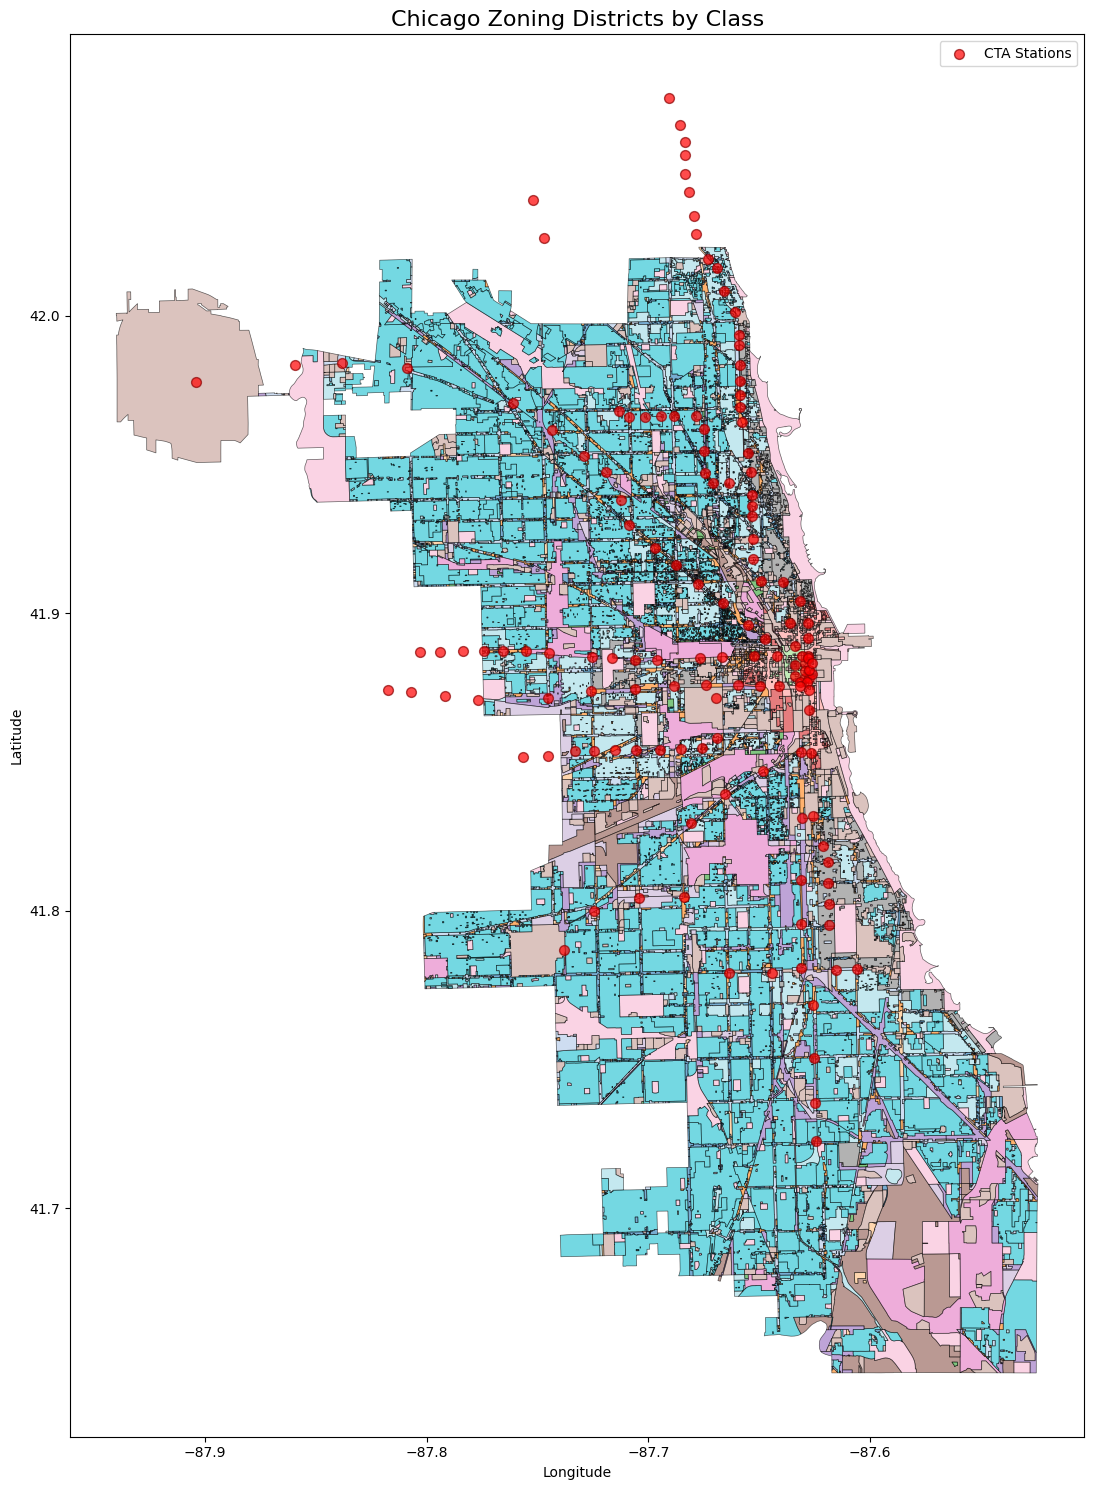

In [83]:
# Plot the zoning districts
fig, ax = plt.subplots(figsize=(15, 15))
zoning_gdf.plot(ax=ax, column='ZONE_TYPE', legend=True, cmap='tab20', alpha=0.6, edgecolor='black', linewidth=0.5)

# Add station locations
ax.scatter(si_aggregated['longitude'], si_aggregated['latitude'], 
           c='red', s=50, alpha=0.7, edgecolors='darkred', linewidth=1, 
           label='CTA Stations', zorder=5)

ax.set_title('Chicago Zoning Districts by Class', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [84]:
si_aggregated

,MAP_ID,STATION_NAME,latitude,longitude,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O,N/S,E/W
0,40010,Austin,41.870851,-87.776812,0,0,1,0,0,0,0,0,0,0,1
1,40020,Harlem/Lake,41.886848,-87.803176,1,0,0,1,0,0,0,0,0,0,1
2,40030,Pulaski,41.885412,-87.725404,1,0,0,1,0,0,0,0,0,0,1
3,40040,Quincy/Wells,41.878723,-87.633740,1,0,0,0,1,1,0,1,1,1,0
4,40050,Davis,42.047710,-87.683543,1,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,41670,Conservatory,41.884904,-87.716523,1,0,0,1,0,0,0,0,0,0,1
140,41680,Oakton-Skokie,42.026243,-87.747221,1,0,0,0,0,0,1,0,0,1,0
141,41690,Cermak-McCormick Place,41.853115,-87.626402,1,0,0,1,0,0,0,0,0,1,0
142,41700,Washington/Wabash,41.883220,-87.626189,1,0,0,1,1,1,0,1,1,1,0


In [85]:
# Create a GeoDataFrame with station locations with shapes representing a 1 mile buffer around each station
si_gdf = gpd.GeoDataFrame(
    si_aggregated,
    geometry=gpd.points_from_xy(si_aggregated['longitude'], si_aggregated['latitude']),
    crs='EPSG:4326'
)

# Project to a projected CRS that uses meters (Chicago area: NAD83 / Illinois East)
si_gdf_projected = si_gdf.to_crs('EPSG:2790')

# Create 1-mile buffers (1 mile = 1609.34 meters)
feet_per_mile = 5280
meters_per_foot = 0.3048
meters_per_mile = feet_per_mile * meters_per_foot  # 1609.344 meters

si_gdf_projected['geometry_mile'] = si_gdf_projected.geometry.buffer(meters_per_mile)
si_gdf_projected['geometry_half_mile'] = si_gdf_projected.geometry.buffer(meters_per_mile / 2)

# WGS84 is EPSG:4326, where coordinates are in decimal degrees
# (x = longitude, y = latitude), not linear units like meters/feet.
si_gdf['geometry_mile'] = gpd.GeoSeries(
    si_gdf_projected['geometry_mile'], crs=si_gdf_projected.crs
).to_crs(si_gdf.crs)

si_gdf['geometry_half_mile'] = gpd.GeoSeries(
    si_gdf_projected['geometry_half_mile'], crs=si_gdf_projected.crs
).to_crs(si_gdf.crs)
display(si_gdf.head())

,MAP_ID,STATION_NAME,latitude,longitude,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O,N/S,E/W,geometry,geometry_mile,geometry_half_mile
0,40010,Austin,41.870851,-87.776812,0,0,1,0,0,0,0,0,0,0,1,POINT (-87.77681 41.87085),"POLYGON ((-87.75743 41.87076, -87.75753 41.869...","POLYGON ((-87.76712 41.8708, -87.76717 41.8700..."
1,40020,Harlem/Lake,41.886848,-87.803176,1,0,0,1,0,0,0,0,0,0,1,POINT (-87.80318 41.88685),"POLYGON ((-87.78379 41.88676, -87.78389 41.885...","POLYGON ((-87.79348 41.8868, -87.79353 41.8860..."
2,40030,Pulaski,41.885412,-87.725404,1,0,0,1,0,0,0,0,0,0,1,POINT (-87.7254 41.88541),"POLYGON ((-87.70601 41.88531, -87.70612 41.883...","POLYGON ((-87.71571 41.88536, -87.71576 41.884..."
3,40040,Quincy/Wells,41.878723,-87.633740,1,0,0,0,1,1,0,1,1,1,0,POINT (-87.63374 41.87872),"POLYGON ((-87.61435 41.8786, -87.61446 41.8771...","POLYGON ((-87.62405 41.87866, -87.6241 41.8779..."
4,40050,Davis,42.047710,-87.683543,1,0,0,0,0,1,0,0,0,1,0,POINT (-87.68354 42.04771),"POLYGON ((-87.6641 42.0476, -87.66421 42.04618...","POLYGON ((-87.67382 42.04765, -87.67388 42.046..."


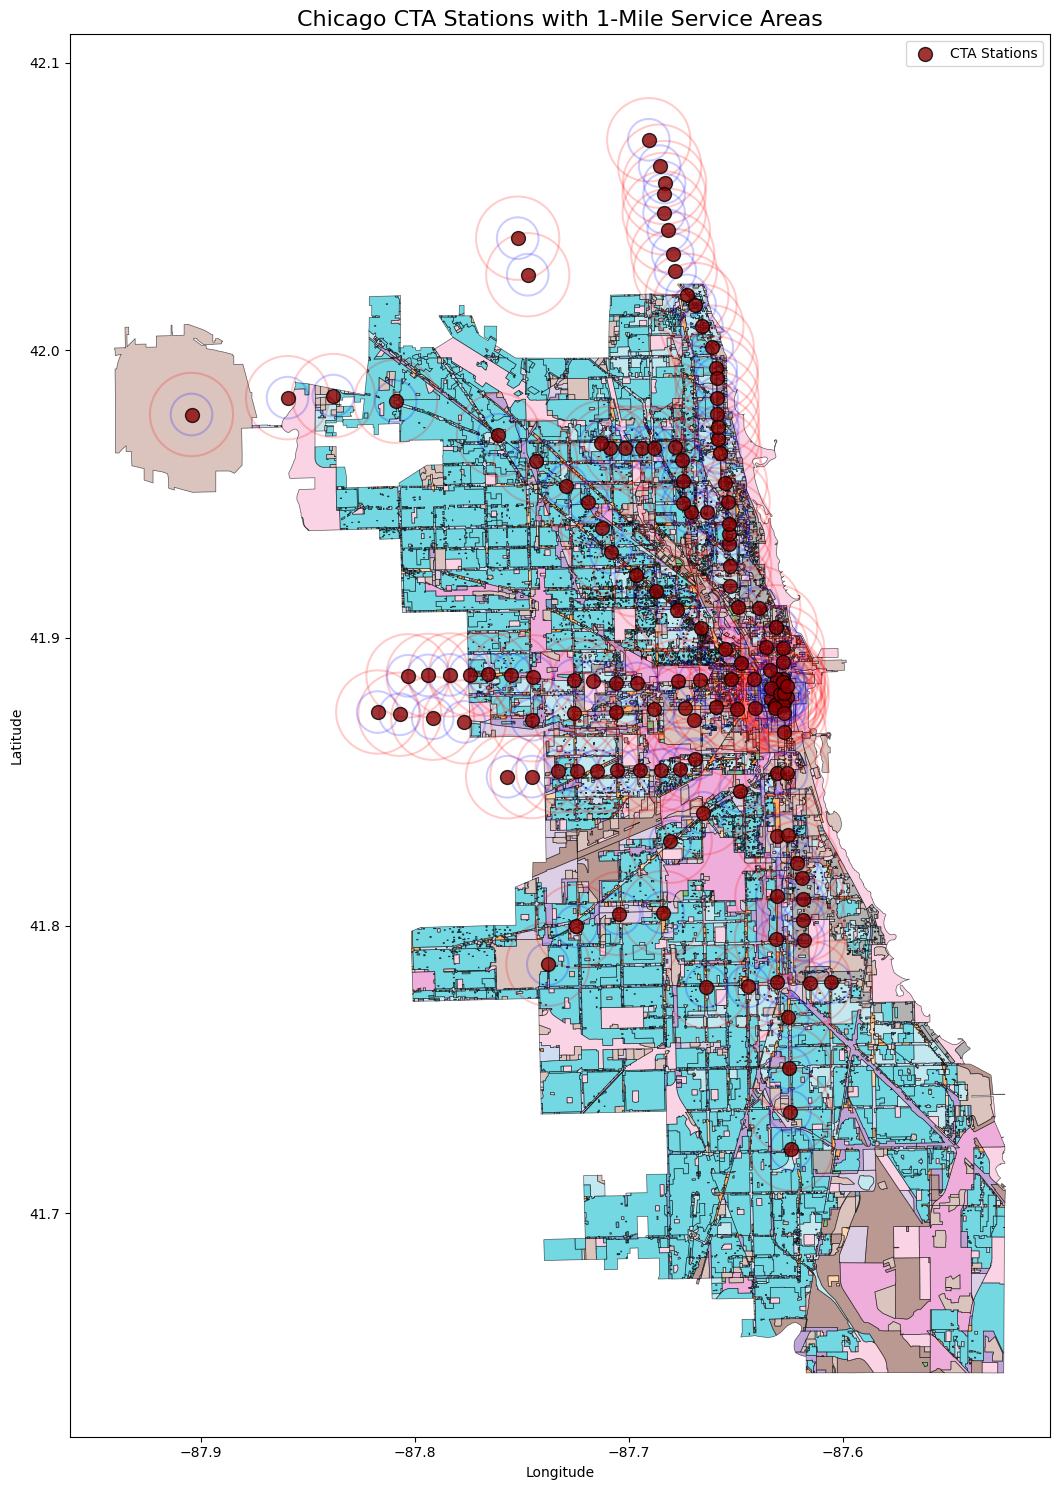

In [86]:
fig, ax = plt.subplots(figsize=(15, 15))
zoning_gdf.plot(ax=ax, column='ZONE_TYPE', legend=True, cmap='tab20', alpha=0.6, edgecolor='black', linewidth=0.5)

# Plot station points
ax.scatter(si_gdf['longitude'], si_gdf['latitude'], 
           c='darkred', s=100, alpha=0.8, edgecolors='black', linewidth=1, 
           label='CTA Stations', zorder=5)

ax.set_title('Chicago CTA Stations with 1-Mile Service Areas', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()


si_gdf['geometry_mile'].plot(
    ax=ax,
    facecolor='none',
    edgecolor='red',
    alpha=0.2,
    linewidth=1.5,
    zorder=4
)

si_gdf['geometry_half_mile'].plot(
    ax=ax,
    facecolor='none',
    edgecolor='blue',
    alpha=0.2,
    linewidth=1.5,
    zorder=4
)

# ax.set_ylim(miny, maxy)
# minx, miny, maxx, maxy = zoning_gdf.total_bounds
# ax.set_xlim(minx, maxx)

plt.show()

In [87]:

for zone_class in zone_classes:
    zone_polygons = zoning_gdf[zoning_gdf['ZONE_TYPE'] == zone_class]['geometry']

    mile_column_name = f"{zone_class}_mile"
    half_mile_column_name = f"{zone_class}_half_mile"
    
    si_gdf[mile_column_name] = si_gdf['geometry_mile'].apply(lambda x: zone_polygons.intersects(x).any()).astype(int)
    si_gdf[half_mile_column_name] = si_gdf['geometry_half_mile'].apply(lambda x: zone_polygons.intersects(x).any()).astype(int)

si_gdf.head()

,MAP_ID,STATION_NAME,latitude,longitude,ADA,RED,BLUE,G,BRN,P,...,RM4.5_mile,RM4.5_half_mile,RM5.5_mile,RM5.5_half_mile,RS_mile,RS_half_mile,RT_mile,RT_half_mile,T_mile,T_half_mile
0,40010,Austin,41.870851,-87.776812,0,0,1,0,0,0,...,0,0,0,0,1,1,1,1,0,0
1,40020,Harlem/Lake,41.886848,-87.803176,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,40030,Pulaski,41.885412,-87.725404,1,0,0,1,0,0,...,0,0,0,0,1,1,1,1,0,0
3,40040,Quincy/Wells,41.878723,-87.633740,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,1,0
4,40050,Davis,42.047710,-87.683543,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [88]:
ridership_with_zoning = pd.merge(station_ridership, si_gdf.drop(columns=['geometry', 'geometry_mile', 'geometry_half_mile']), left_on='MAP_ID', right_on='MAP_ID', how='left')

ridership_with_zoning.head()

,station_id,stationname,date,daytype,rides,AWND,PRCP,SNOW,SNWD,TAVG,...,RM4.5_mile,RM4.5_half_mile,RM5.5_mile,RM5.5_half_mile,RS_mile,RS_half_mile,RT_mile,RT_half_mile,T_mile,T_half_mile
0,41280,Jefferson Park,2017-12-22,W,6104,6.93,0.00,0.0,0.0,38.0,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0
1,41000,Cermak-Chinatown,2017-12-18,W,3636,11.41,0.01,0.0,0.0,42.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0
2,40280,Central-Lake,2017-12-02,A,1270,4.25,0.00,0.0,0.0,42.0,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0
3,40140,Dempster-Skokie,2017-12-19,W,1759,12.08,0.00,0.0,0.0,43.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,40690,Dempster,2017-12-03,U,499,6.26,0.00,0.0,0.0,43.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [89]:
# Build a modeling dataset from ridership_with_zoning
model_df = ridership_with_zoning.copy()

# Keep core temporal/transit features + zoning proximity flags
base_features = [
    'days_since_2000', 'post_shutdown', 'season_Spring', 'season_Summer', 'season_Winter', 'year', 'PRCP', 'TAVG', 'SNOW', 'SNWD', 'Fog_Ice_Fog', 'Blowing_Snow', "latitude_x", "longitude_x", 'ADA_x', 'RED_x', 'BLUE_x', 'G_x', 'BRN_x', 'P_x', 'Y_x', 'Pnk_x', 'O_x', 'N/S_x', 'E/W_x'
]
zoning_features = [c for c in model_df.columns if c.endswith('_mile') or c.endswith('_half_mile')]
feature_cols = [c for c in base_features if c in model_df.columns] + zoning_features

X = model_df[feature_cols].copy()
y = model_df['rides'].copy()

# Add daytype as dummy variables
daytype_dummies = pd.get_dummies(model_df['daytype'], prefix='daytype', drop_first=True, dtype=int)
X = pd.concat([X, daytype_dummies], axis=1)

# Convert boolean columns to int
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

# Force all predictors/target to numeric for statsmodels compatibility
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

# Drop rows with any missing values in features/target
valid_mask = X.notna().all(axis=1) & y.notna()
X = X.loc[valid_mask]
y = y.loc[valid_mask]

# Optional sampling for speed on very large dataset
sample_n = min(200_000, len(X))
sample_idx = X.sample(n=sample_n, random_state=42).index
#X = X.loc[sample_idx]
#y = y.loc[sample_idx]

In [90]:
X.head()

,days_since_2000,post_shutdown,season_Spring,season_Summer,season_Winter,year,PRCP,TAVG,SNOW,SNWD,...,RM5.5_mile,RM5.5_half_mile,RS_mile,RS_half_mile,RT_mile,RT_half_mile,T_mile,T_half_mile,daytype_U,daytype_W
0,6565,0,0,0,1,2017,0.00,38.0,0.0,0.0,...,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0,1
1,6561,0,0,0,1,2017,0.01,42.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0,1
2,6545,0,0,0,1,2017,0.00,42.0,0.0,0.0,...,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0,0
3,6562,0,0,0,1,2017,0.00,43.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1
4,6546,0,0,0,1,2017,0.00,43.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0


In [91]:
# 1. Define your cutoff (approximate days from 2000 to end of 2023)
# 24 years * 365.25 days = 8766
#cutoff_value = 8766
cutoff_value = 25*365.25

# 2. Create the mask
train_mask = X['days_since_2000'] <= cutoff_value
test_mask = X['days_since_2000'] > cutoff_value

# 3. Split the data
X_train, X_test = X.loc[train_mask], X.loc[test_mask]
y_train, y_test = y.loc[train_mask], y.loc[test_mask]

print(f"Training rows: {len(X_train)} (Through 2023)")
print(f"Testing rows: {len(X_test)} (2024 onwards)")

Training rows: 839539 (Through 2023)
Testing rows: 47520 (2024 onwards)


In [92]:
#Fit OLS model
X_train_const = sm.add_constant(X_train, has_constant='add')
X_test_const = sm.add_constant(X_test, has_constant='add')

ols_model = sm.OLS(y_train, X_train_const).fit()

# Predict and evaluate
y_pred = ols_model.predict(X_test_const)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:,.2f}")
print(f"MAE:  {mae:,.2f}")
print(f"R²:   {r2:.4f}")

# Full statistical summary
print(ols_model.summary())

RMSE: 1,400.94
MAE:  1,051.52
R²:   0.5581
                            OLS Regression Results                            
Dep. Variable:                  rides   R-squared:                       0.688
Model:                            OLS   Adj. R-squared:                  0.688
Method:                 Least Squares   F-statistic:                 2.572e+04
Date:                Sat, 28 Feb 2026   Prob (F-statistic):               0.00
Time:                        15:52:45   Log-Likelihood:            -7.4246e+06
No. Observations:              839539   AIC:                         1.485e+07
Df Residuals:                  839466   BIC:                         1.485e+07
Df Model:                          72                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [93]:
#Try decision tree
# Initialize and fit
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_dt = dt_model.predict(X_test)

print(f"Decision Tree RMSE: {mean_squared_error(y_test, y_pred_dt)**0.5:,.2f}")
print(f"Decision Tree R²:   {r2_score(y_test, y_pred_dt):.4f}")

Decision Tree RMSE: 826.03
Decision Tree R²:   0.8464


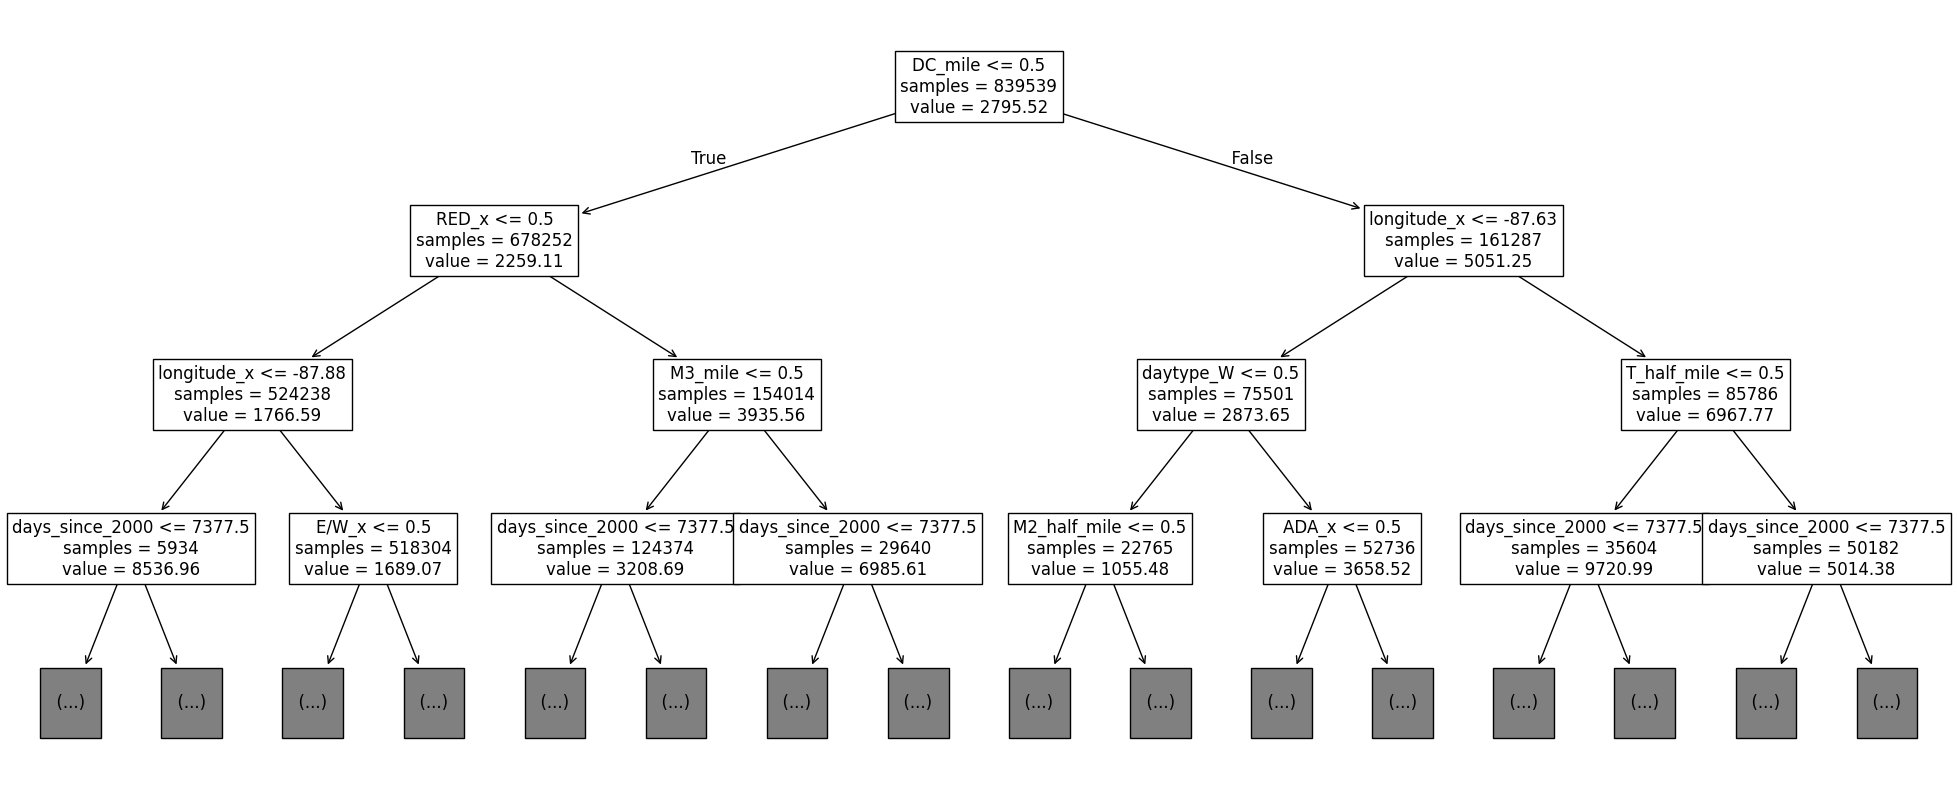

In [94]:
plt.figure(figsize=(25,10))
plot_tree(dt_model,
          feature_names=X_train.columns,
          max_depth=3,
          filled=False,        # Removes the orange background
          impurity=False,     # Removes the "squared_error" text to declutter
          fontsize=12,        # Increases text size
          precision=2)        # Rounds numbers to 2 decimals
plt.show()

Top Features:
             Feature  Importance
0   days_since_2000    0.162577
13      longitude_x    0.148626
37          DC_mile    0.144865
74        daytype_W    0.109500
15            RED_x    0.085609
72      T_half_mile    0.067235
49          M3_mile    0.060708
12       latitude_x    0.035438
14            ADA_x    0.030029
16           BLUE_x    0.023158


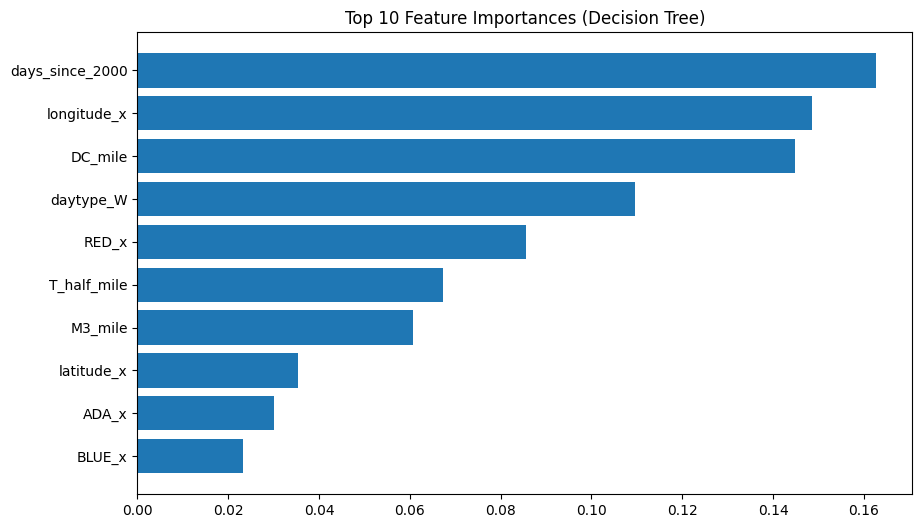

In [95]:
#Evaluate feature importance
importances = dt_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Top Features:\n", feature_importance_df.head(10))

#Visualize results
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:10], feature_importance_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Decision Tree)")
plt.show()

In [96]:
def ablation_test(list_feats):
    for feat in list_feats:
        X_train_ablated = X_train.drop(columns=[feat])
        X_test_ablated = X_test.drop(columns=[feat])

        dt_ablated = DecisionTreeRegressor(max_depth=10, random_state=42)
        dt_ablated.fit(X_train_ablated, y_train)
        y_pred_ablated = dt_ablated.predict(X_test_ablated)
        print(f"Ablated ({feat} removed) RMSE: {mean_squared_error(y_test, y_pred_ablated)**0.5:,.2f}")

ablation_test(['days_since_2000', 'longitude_x', 'DC_mile', 'daytype_W', 'RED_x', 'T_half_mile',
               'M3_mile', 'latitude_x', 'ADA_x', 'BLUE_x'])

Ablated (days_since_2000 removed) RMSE: 798.95
Ablated (longitude_x removed) RMSE: 807.15
Ablated (DC_mile removed) RMSE: 908.60
Ablated (daytype_W removed) RMSE: 860.76
Ablated (RED_x removed) RMSE: 962.96
Ablated (T_half_mile removed) RMSE: 825.40
Ablated (M3_mile removed) RMSE: 825.05
Ablated (latitude_x removed) RMSE: 832.21
Ablated (ADA_x removed) RMSE: 870.06
Ablated (BLUE_x removed) RMSE: 907.39


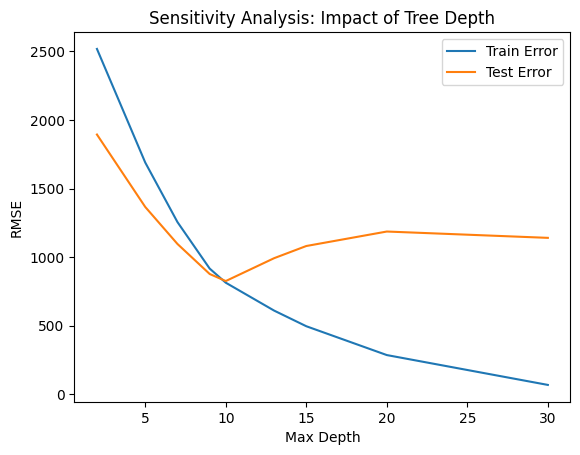

In [97]:
depths = [2, 5, 7, 9, 10, 13, 15, 20, 30]
train_errors = []
test_errors = []

for d in depths:
    model = DecisionTreeRegressor(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    # Calculate RMSE for both sets
    train_rmse = mean_squared_error(y_train, model.predict(X_train))**0.5
    test_rmse = mean_squared_error(y_test, model.predict(X_test))**0.5

    train_errors.append(train_rmse)
    test_errors.append(test_rmse)

plt.plot(depths, train_errors, label='Train Error')
plt.plot(depths, test_errors, label='Test Error')
plt.xlabel('Max Depth')
plt.ylabel('RMSE')
plt.title('Sensitivity Analysis: Impact of Tree Depth')
plt.legend()
plt.show()

In [98]:
# 1. Calculate errors and sort (same as before)
results = X_test.copy()
results['Actual'] = y_test
results['Predicted'] = y_pred_dt
results['Abs_Error'] = abs(results['Actual'] - results['Predicted'])

# 2. Get top 3 as a DataFrame
# We use .head(3) to keep it concise
top_failures_df = results.sort_values(by='Abs_Error', ascending=False).head(3)

# 3. Display the DataFrame
# If you are in a Jupyter Notebook, just typing the variable name prints a nice table
top_failures_df

,days_since_2000,post_shutdown,season_Spring,season_Summer,season_Winter,year,PRCP,TAVG,SNOW,SNWD,...,RS_half_mile,RT_mile,RT_half_mile,T_mile,T_half_mile,daytype_U,daytype_W,Actual,Predicted,Abs_Error
1259743,9205,1,1,0,0,2025,0.31,62.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0,0,24425,6940.508516,17484.491484
1259898,9205,1,1,0,0,2025,0.31,62.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0,0,25011,8116.126521,16894.873479
1292447,9416,1,0,0,0,2025,0.00,59.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,1,0,15472,1891.173254,13580.826746


In [99]:
#The biggest miss was on March 15, 2025 (9205 days after 2000) at Grand (Red Line) and Clark/Lake (Transfer Station), followed by October 12, 2025 (9416 days) at Cermak-Chinatown (Red Line).
#Likely due to St. Patrick's Day for the former and the Chicago Marathon for the latter

In [100]:
#Try random forest
# Initialize and fit
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_rf = rf_model.predict(X_test)

print(f"Random Forest RMSE: {mean_squared_error(y_test, y_pred_rf)**0.5:,.2f}")
print(f"Random Forest R²:   {r2_score(y_test, y_pred_rf):.4f}")

Random Forest RMSE: 900.72
Random Forest R²:   0.8173


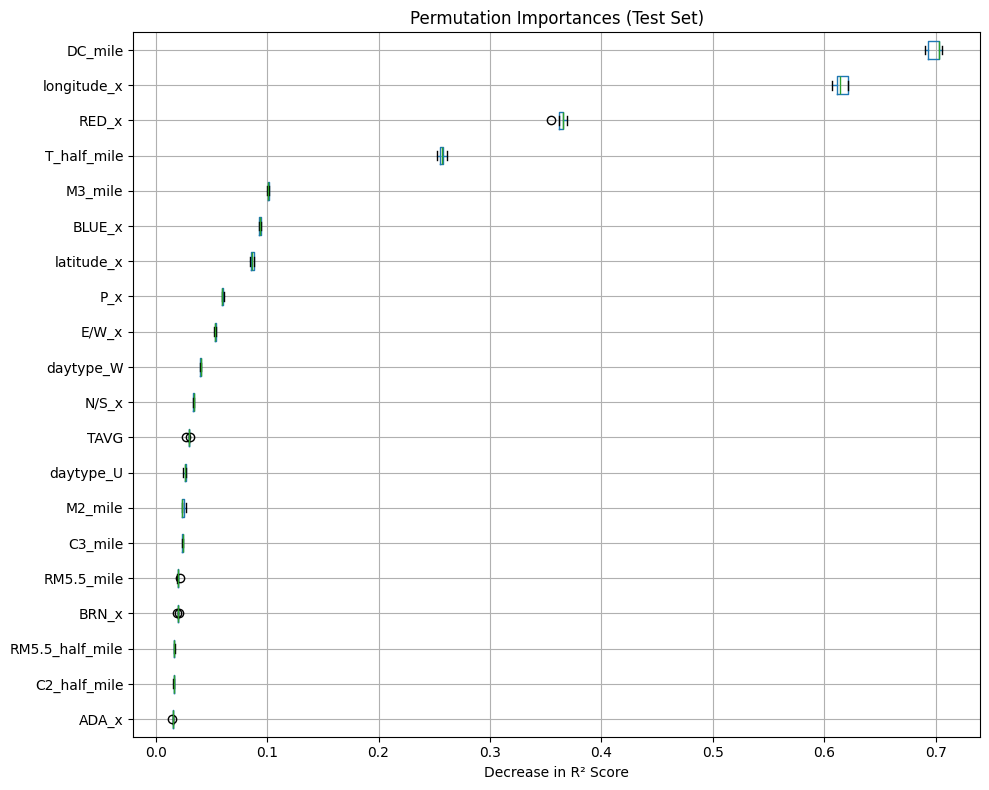

In [101]:
result = permutation_importance(
    rf_model, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1
)

# Organize the results
perm_sorted_idx = result.importances_mean.argsort()
perm_df = pd.DataFrame(
    result.importances[perm_sorted_idx].T,
    columns=X.columns[perm_sorted_idx]
)

# Plotting the result
plt.figure(figsize=(10, 8))
perm_df.iloc[:, -20:].boxplot(vert=False, manage_ticks=True)
plt.title("Permutation Importances (Test Set)")
plt.xlabel("Decrease in R² Score")
plt.tight_layout()
plt.show()

In [102]:
#Trying because Huber Regressor treats small errors as squared (like linear regression) but treats large errors (outliers) as linear so it's more robust to outliers
# 1. Create the Robust Pipeline
# epsilon: A smaller epsilon (closer to 1.0) makes it MORE robust to outliers.
# The default is 1.35, which is usually a good balance.
huber_pipeline = make_pipeline(
    StandardScaler(),
    HuberRegressor(epsilon=1.35, max_iter=1000)
)

# 2. Train the model
huber_pipeline.fit(X_train, y_train)

# 3. Predict
y_pred_huber = huber_pipeline.predict(X_test)

# 4. Evaluate
print(f"Huber RMSE: {mean_squared_error(y_test, y_pred_huber)**0.5:,.2f}")
print(f"Huber R²:   {r2_score(y_test, y_pred_huber):.4f}")

Huber RMSE: 1,275.19
Huber R²:   0.6339


In [103]:
# PCA on ridership_with_zoning (with fallback to ridershipo_with_zoning if that exists)
pca_source_df = ridership_with_zoning.copy()

# Drop non-feature columns that are not directly usable
pca_features = pca_source_df.drop(columns=['date', 'rides'], errors='ignore')

# Encode categorical fields
cat_cols = pca_features.select_dtypes(include=['object', 'string', 'category']).columns
pca_features = pd.get_dummies(pca_features, columns=cat_cols, drop_first=True, dtype=int)

# Convert bools and coerce to numeric
bool_cols = pca_features.select_dtypes(include='bool').columns
pca_features[bool_cols] = pca_features[bool_cols].astype(int)
pca_features = pca_features.apply(pd.to_numeric, errors='coerce').dropna()

# Optional sampling for speed
sample_n = min(200_000, len(pca_features))
pca_features = pca_features.sample(n=sample_n)

# Standardize then fit PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_features)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)
n95 = np.argmax(cum_explained >= 0.95) + 1

print(f"Rows used for PCA: {len(pca_features):,}")
print(f"Original feature count: {pca_features.shape[1]:,}")
print(f"Components to explain >=95% variance: {n95}")
print(f"First 10 explained variance ratios:\n{explained[:10]}")

# PCA scores dataframe (first n95 components)
si_pca_scores = pd.DataFrame(
    X_pca[:, :n95],
    columns=[f'PC{i+1}' for i in range(n95)],
    index=pca_features.index
)
display(si_pca_scores.head())


Rows used for PCA: 200,000
Original feature count: 466
Components to explain >=95% variance: 138
First 10 explained variance ratios:
[0.04416703 0.02775907 0.02105586 0.01501131 0.01412884 0.01214977
 0.01103401 0.01090762 0.01046884 0.01041722]


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC129,PC130,PC131,PC132,PC133,PC134,PC135,PC136,PC137,PC138
617233,3.787268,-0.413724,-0.143890,1.059152,-3.115332,2.660252,-1.645774,1.718865,-3.879078,-0.398064,...,-0.161774,-0.025761,0.330822,0.051994,0.046040,-0.027230,0.102949,-0.042899,0.059453,0.385301
1228021,-6.470925,5.793417,-3.824278,-4.829123,-2.982794,0.377946,1.226560,1.747845,0.717347,-3.001708,...,0.125976,-0.034538,-0.005173,-0.083316,0.031687,0.010635,-0.057026,0.038299,0.060352,-0.205964
824646,3.504962,-0.675746,4.498093,1.917583,0.738678,-0.334592,-0.836090,-1.370644,2.308247,-0.262408,...,-2.972873,-2.313383,0.908771,0.937658,-0.215897,0.160955,-2.695697,0.523163,0.951412,3.367964
786796,3.798664,0.106752,0.930586,1.474480,1.146463,0.703141,-4.181172,-1.394020,0.604275,0.560129,...,2.003797,-1.879330,-1.651419,1.528833,-2.448711,-2.292590,-0.428533,-1.126493,-0.783016,1.521413
965193,3.352108,-0.600939,4.647278,1.935750,0.680361,0.033987,-1.348090,-1.831902,2.810571,-0.473698,...,0.239327,-0.280434,-0.089582,-0.103808,-0.200087,-0.124918,0.043001,-0.023113,-0.036179,0.173474


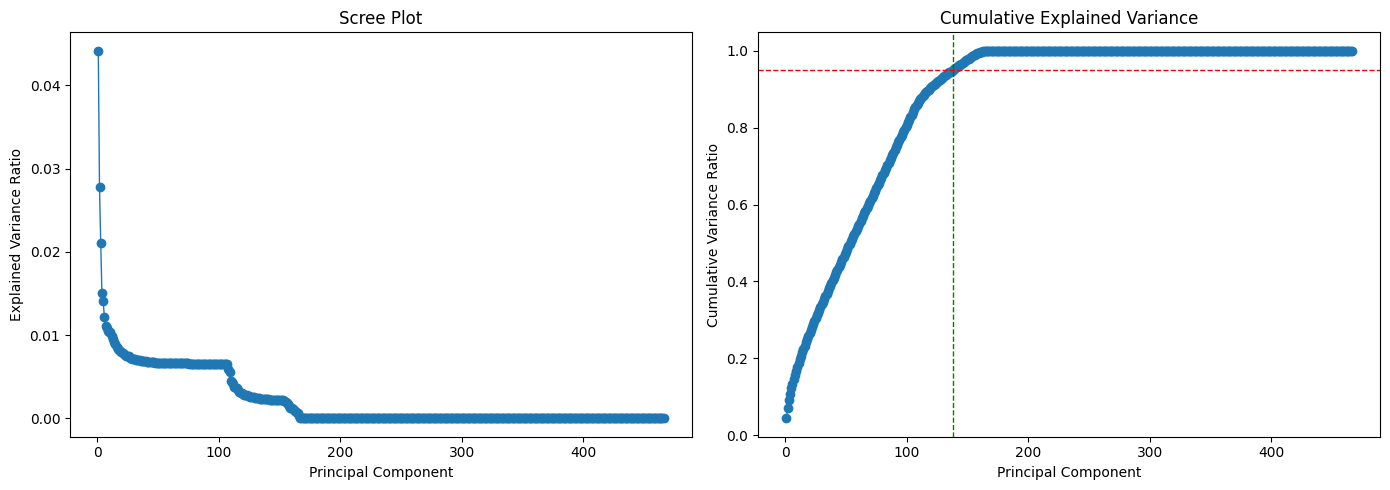

In [104]:

# Scree + cumulative variance plots
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(range(1, len(explained) + 1), explained, marker='o', linewidth=1)
ax[0].set_title('Scree Plot')
ax[0].set_xlabel('Principal Component')
ax[0].set_ylabel('Explained Variance Ratio')

ax[1].plot(range(1, len(cum_explained) + 1), cum_explained, marker='o', linewidth=1)
ax[1].axhline(0.95, color='red', linestyle='--', linewidth=1)
ax[1].axvline(n95, color='green', linestyle='--', linewidth=1)
ax[1].set_title('Cumulative Explained Variance')
ax[1].set_xlabel('Principal Component')
ax[1].set_ylabel('Cumulative Variance Ratio')

plt.tight_layout()
plt.show()

In [105]:
feature_names = pca_features.columns

# Loadings matrix: rows=original features, cols=PCs
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)
# Remove station name features from loadings to declutter interpretation
station_name_mask = (
    loadings.index.str.startswith("stationname_") |
    loadings.index.str.startswith("STATION_NAME_")
)
loadings = loadings.loc[~station_name_mask].copy()
# Show top contributors for first 3 PCs
for pc in ["PC1", "PC2", "PC3"]:
    print(f"\nTop + contributors to {pc}")
    print(loadings[pc].sort_values(ascending=False).head(10))
    print(f"\nTop - contributors to {pc}")
    print(loadings[pc].sort_values(ascending=True).head(10))

# Contribution strength (absolute loading) for PC1/PC2/PC3
pc123_contrib = loadings[["PC1", "PC2", "PC3"]].abs().sort_values("PC1", ascending=False)
display(pc123_contrib.head(20))


Top + contributors to PC1
B3_half_mile    0.206312
C1_half_mile    0.201716
RT_half_mile    0.201539
B1_half_mile    0.197707
B1_mile         0.197021
B2_mile         0.196680
RT_mile         0.192395
RM_half_mile    0.189826
M1_mile         0.185701
RM_mile         0.183946
Name: PC1, dtype: float64

Top - contributors to PC1
DC_half_mile   -0.100249
P_y            -0.095584
P_x            -0.095584
DC_mile        -0.090713
DX_half_mile   -0.076087
latitude_y     -0.074811
latitude_x     -0.074811
DX_mile        -0.067709
DR_mile        -0.061576
DS_mile        -0.061222
Name: PC1, dtype: float64

Top + contributors to PC2
DX_mile         0.243639
DR_mile         0.242921
DS_mile         0.242878
DX_half_mile    0.241141
DC_mile         0.229835
DC_half_mile    0.207836
DS_half_mile    0.199897
DR_half_mile    0.196061
longitude_x     0.177101
longitude_y     0.177101
Name: PC2, dtype: float64

Top - contributors to PC2
RS_half_mile      -0.106942
latitude_x        -0.104946
latitude

,PC1,PC2,PC3
B3_half_mile,0.206312,0.038726,0.009086
C1_half_mile,0.201716,0.012686,0.014004
RT_half_mile,0.201539,0.057997,0.018462
B1_half_mile,0.197707,0.052962,0.033182
B1_mile,0.197021,0.005660,0.011004
B2_mile,0.196680,0.028340,0.021462
RT_mile,0.192395,0.005946,0.010582
RM_half_mile,0.189826,0.017452,0.002973
M1_mile,0.185701,0.058657,0.019695
RM_mile,0.183946,0.048176,0.010615


In [106]:
def get_top_contributors(loadings_df, pc_count, top_n=10):
    top_features = set()
    for i in range(1, pc_count + 1):
        pc_col = f"PC{i}"
        top_features.update(loadings_df[pc_col].abs().sort_values(ascending=False).head(top_n).index)
    return list(top_features)

result = get_top_contributors(loadings, pc_count=3, top_n=10)
result

['B2_mile',
 'Pnk_y',
 'RT_mile',
 'Pnk_x',
 'DS_half_mile',
 'RED_y',
 'RT_half_mile',
 'B1_half_mile',
 'DR_half_mile',
 'B3_half_mile',
 'RED_x',
 'RM_mile',
 'DC_mile',
 'longitude_y',
 'B1_mile',
 'E/W_x',
 'DC_half_mile',
 'DX_half_mile',
 'DX_mile',
 'M1_mile',
 'N/S_x',
 'C1_half_mile',
 'RM_half_mile',
 'N/S_y',
 'DS_mile',
 'longitude_x',
 'E/W_y',
 'DR_mile']

In [107]:
# Add PCA columns to ridership_with_zoning
# Prepare features for PCA (same process as before)
pca_prep_df = ridership_with_zoning.copy()
cat_cols_pca = pca_prep_df.select_dtypes(include=['object', 'string', 'category']).columns
pca_prep_df = pd.get_dummies(pca_prep_df, columns=cat_cols_pca, drop_first=True, dtype=int)

# Convert bools to int and coerce to numeric
bool_cols_pca = pca_prep_df.select_dtypes(include='bool').columns
pca_prep_df[bool_cols_pca] = pca_prep_df[bool_cols_pca].astype(int)
pca_prep_df = pca_prep_df.apply(pd.to_numeric, errors='coerce')

# Drop rows with any NaN values for PCA fitting
pca_prep_df_clean = pca_prep_df.dropna()

# Standardize and fit PCA
scaler_final = StandardScaler()
X_scaled_final = scaler_final.fit_transform(pca_prep_df_clean)

pca_final = PCA()
X_pca_final = pca_final.fit_transform(X_scaled_final)

# Use 95% variance threshold
cum_var_final = np.cumsum(pca_final.explained_variance_ratio_)
n_components_95 = np.argmax(cum_var_final >= 0.95) + 1

print(f"Number of components needed for 95% variance: {n_components_95}")
print(f"Total rows used for PCA: {len(pca_prep_df_clean):,}")

# Create dataframe with PC columns
pca_columns_df = pd.DataFrame(
    X_pca_final[:, :n_components_95],
    columns=[f'PC{i+1}' for i in range(n_components_95)],
    index=pca_prep_df_clean.index
)

# Add PCA columns to ridership_with_zoning (aligned by index)
ridership_with_zoning_pca = ridership_with_zoning.copy()
ridership_with_zoning_pca = ridership_with_zoning_pca.loc[pca_columns_df.index].copy()
ridership_with_zoning_pca = pd.concat([ridership_with_zoning_pca.reset_index(drop=True), 
                                        pca_columns_df.reset_index(drop=True)], axis=1)

print(f"\nOriginal ridership_with_zoning shape: {ridership_with_zoning.shape}")
print(f"ridership_with_zoning_pca shape: {ridership_with_zoning_pca.shape}")
print(f"New PC columns: {list(ridership_with_zoning_pca.columns[-n_components_95:])}")

display(ridership_with_zoning_pca.head())

Number of components needed for 95% variance: 139
Total rows used for PCA: 886,339

Original ridership_with_zoning shape: (1298399, 106)
ridership_with_zoning_pca shape: (886339, 245)
New PC columns: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19', 'PC20', 'PC21', 'PC22', 'PC23', 'PC24', 'PC25', 'PC26', 'PC27', 'PC28', 'PC29', 'PC30', 'PC31', 'PC32', 'PC33', 'PC34', 'PC35', 'PC36', 'PC37', 'PC38', 'PC39', 'PC40', 'PC41', 'PC42', 'PC43', 'PC44', 'PC45', 'PC46', 'PC47', 'PC48', 'PC49', 'PC50', 'PC51', 'PC52', 'PC53', 'PC54', 'PC55', 'PC56', 'PC57', 'PC58', 'PC59', 'PC60', 'PC61', 'PC62', 'PC63', 'PC64', 'PC65', 'PC66', 'PC67', 'PC68', 'PC69', 'PC70', 'PC71', 'PC72', 'PC73', 'PC74', 'PC75', 'PC76', 'PC77', 'PC78', 'PC79', 'PC80', 'PC81', 'PC82', 'PC83', 'PC84', 'PC85', 'PC86', 'PC87', 'PC88', 'PC89', 'PC90', 'PC91', 'PC92', 'PC93', 'PC94', 'PC95', 'PC96', 'PC97', 'PC98', 'PC99', 'PC100', 'PC101'

,station_id,stationname,date,daytype,rides,AWND,PRCP,SNOW,SNWD,TAVG,...,PC130,PC131,PC132,PC133,PC134,PC135,PC136,PC137,PC138,PC139
0,41280,Jefferson Park,2017-12-22,W,6104,6.93,0.00,0.0,0.0,38.0,...,0.103573,0.068896,-0.179708,-0.100125,-0.052711,0.058344,0.042932,-0.074481,0.047856,0.011308
1,41000,Cermak-Chinatown,2017-12-18,W,3636,11.41,0.01,0.0,0.0,42.0,...,0.001174,-0.128903,0.138598,0.099319,0.006906,0.031879,-0.069503,0.023505,-0.005721,-0.082077
2,40280,Central-Lake,2017-12-02,A,1270,4.25,0.00,0.0,0.0,42.0,...,1.378642,1.275416,0.273780,0.875612,2.839222,0.031733,-0.055817,-1.554985,0.021949,-0.854195
3,40140,Dempster-Skokie,2017-12-19,W,1759,12.08,0.00,0.0,0.0,43.0,...,0.157236,-0.040257,0.192646,0.043073,-0.003211,-0.112682,-0.022356,0.055405,0.049638,-0.027702
4,40690,Dempster,2017-12-03,U,499,6.26,0.00,0.0,0.0,43.0,...,0.195853,0.092818,0.145236,0.033760,0.115671,-0.012237,-0.027833,-0.034262,-0.041146,-0.007965


In [108]:
def get_pc_cols(n):
    return [f"PC{i+1}" for i in range(n)]

# Build PCA-only modeling frame
pc_cols = sorted(
    [c for c in ridership_with_zoning_pca.columns if re.fullmatch(r"PC\d+", c)],
    key=lambda x: int(x[2:])
)

pc_model_df = ridership_with_zoning_pca[['days_since_2000', 'rides'] + pc_cols].copy()
pc_model_df = pc_model_df.apply(pd.to_numeric, errors='coerce').dropna()

X_pc = pc_model_df[['days_since_2000'] + pc_cols]
y_pc = pc_model_df['rides']

# Time-based split (reuse existing cutoff if present)
cutoff_value_pc = cutoff_value if 'cutoff_value' in globals() else 25 * 365.25
train_mask_pc = X_pc['days_since_2000'] <= cutoff_value_pc
test_mask_pc = X_pc['days_since_2000'] > cutoff_value_pc

X_train_pc, X_test_pc = X_pc.loc[train_mask_pc], X_pc.loc[test_mask_pc]
y_train_pc, y_test_pc = y_pc.loc[train_mask_pc], y_pc.loc[test_mask_pc]

print(f"PC train rows: {len(X_train_pc)}")
print(f"PC test rows:  {len(X_test_pc)}")
print(f"Available PC columns: {len(pc_cols)}")

# Evaluate different numbers of PCs
results = []
for count in range(1,10):
    cols = get_pc_cols(count)
    X_train_subset = X_train_pc[cols]
    X_test_subset = X_test_pc[cols]

    model = DecisionTreeRegressor(max_depth=10)
    model.fit(X_train_subset, y_train_pc)
    y_pred_subset = model.predict(X_test_subset)

    rmse_subset = mean_squared_error(y_test_pc, y_pred_subset) ** 0.5
    r2_subset = r2_score(y_test_pc, y_pred_subset)
    results.append((count, rmse_subset, r2_subset))
# Display results
results_df = pd.DataFrame(results, columns=["PC Count", "RMSE", "R2"])
print(results_df)

PC train rows: 839539
PC test rows:  46800
Available PC columns: 139
   PC Count         RMSE        R2
0         1  1411.523047  0.548810
1         2  1071.410676  0.740047
2         3   825.550951  0.845663
3         4   788.483226  0.859211
4         5   849.964659  0.836399
5         6   896.259864  0.818092
6         7   845.356204  0.838169
7         8   846.204503  0.837844
8         9   913.009502  0.811230


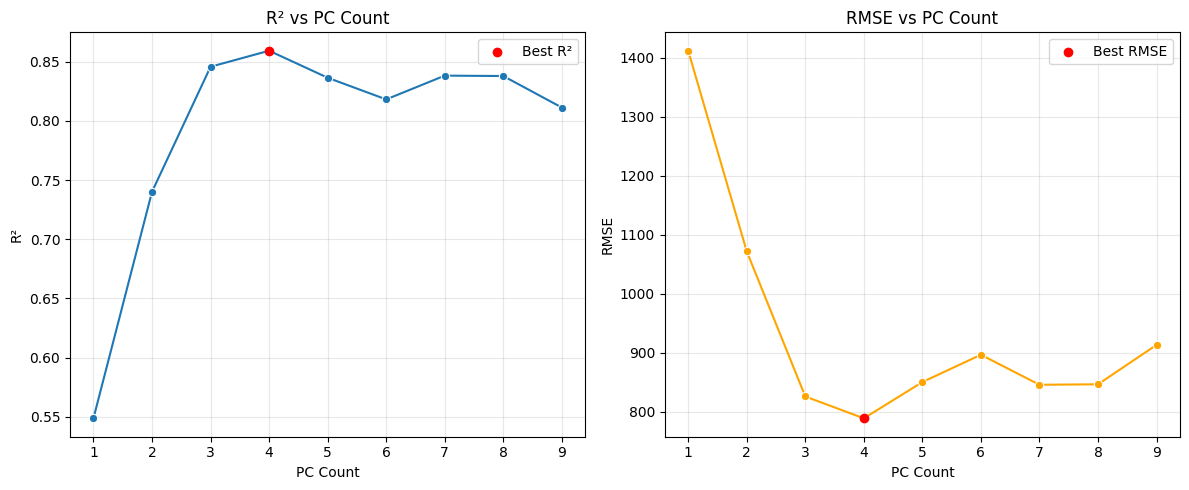

Best by R²   -> PC Count: 4, R²: 0.8592
Best by RMSE -> PC Count: 4, RMSE: 788.48


In [109]:
# Dual plots: R² and RMSE vs PC Count
if 'results_df' in globals() and {'PC Count', 'RMSE', 'R2'}.issubset(results_df.columns):
    plot_df = results_df.copy()
elif 'results' in globals():
    # Fallback if tuple-list exists: (PC Count, RMSE, R2)
    plot_df = pd.DataFrame(results, columns=['PC Count', 'RMSE', 'R2'])
else:
    raise ValueError("No PCA evaluation results found. Run the PCA model comparison cell first.")

plot_df = plot_df.sort_values('PC Count').reset_index(drop=True)

best_r2_idx = plot_df['R2'].idxmax()
best_rmse_idx = plot_df['RMSE'].idxmin()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

# R² plot
sns.lineplot(data=plot_df, x='PC Count', y='R2', marker='o', ax=axes[0])
axes[0].scatter(
    plot_df.loc[best_r2_idx, 'PC Count'],
    plot_df.loc[best_r2_idx, 'R2'],
    color='red',
    zorder=5,
    label='Best R²'
)
axes[0].set_title('R² vs PC Count')
axes[0].set_xlabel('PC Count')
axes[0].set_ylabel('R²')
axes[0].grid(alpha=0.3)
axes[0].legend()

# RMSE plot
sns.lineplot(data=plot_df, x='PC Count', y='RMSE', marker='o', ax=axes[1], color='orange')
axes[1].scatter(
    plot_df.loc[best_rmse_idx, 'PC Count'],
    plot_df.loc[best_rmse_idx, 'RMSE'],
    color='red',
    zorder=5,
    label='Best RMSE'
)
axes[1].set_title('RMSE vs PC Count')
axes[1].set_xlabel('PC Count')
axes[1].set_ylabel('RMSE')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Best by R²   -> PC Count: {int(plot_df.loc[best_r2_idx, 'PC Count'])}, R²: {plot_df.loc[best_r2_idx, 'R2']:.4f}")
print(f"Best by RMSE -> PC Count: {int(plot_df.loc[best_rmse_idx, 'PC Count'])}, RMSE: {plot_df.loc[best_rmse_idx, 'RMSE']:.2f}")

By using principal components to predict ridership, performance seemed to peak using 4 principal components. Let's see if we can use the 4 principal components to feature engineer a lighter model that uses the top contributing features for all 4 principal coompents

In [115]:
plot_data = []
light_ridership_df = ridership_with_zoning.copy()

# print(ridership_with_zoning.columns)

# Iterate through different numbers of top features to evaluate model performance
for top_features_count in range(10, 100, 10):
    top_features = get_top_contributors(loadings, pc_count=4, top_n=top_features_count)
    
    light_ridership_df = ridership_with_zoning.copy()
    cat_cols = light_ridership_df.select_dtypes(include=['string', 'category']).columns.tolist()
    light_ridership_df = pd.get_dummies(light_ridership_df, columns=cat_cols, drop_first=True, dtype=int)
    light_ridership_df = light_ridership_df[top_features + ['rides']].dropna()
    
    X_light = light_ridership_df.drop(columns=['rides'])
    y_light = light_ridership_df['rides']
    X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_light, y_light, test_size=0.2, random_state=42)
    model_l = DecisionTreeRegressor(max_depth=15)
    model_l.fit(X_train_l, y_train_l)
    y_pred_l = model_l.predict(X_test_l)
    rmse_l = mean_squared_error(y_test_l, y_pred_l)**0.5
    r2_l = r2_score(y_test_l, y_pred_l)
    print(f"PCs: 4, Top N: {top_features_count} => RMSE: {rmse_l:,.2f}, R²: {r2_l:.4f}")
    plot_data.append({
        'Top_features': top_features_count,
        'RMSE': rmse_l,
        'R2': r2_l
    })

PCs: 4, Top N: 10 => RMSE: 1,778.65, R²: 0.6541
PCs: 4, Top N: 20 => RMSE: 1,778.65, R²: 0.6541
PCs: 4, Top N: 30 => RMSE: 1,778.65, R²: 0.6541
PCs: 4, Top N: 40 => RMSE: 1,778.70, R²: 0.6541
PCs: 4, Top N: 50 => RMSE: 1,778.70, R²: 0.6541
PCs: 4, Top N: 60 => RMSE: 1,778.70, R²: 0.6541
PCs: 4, Top N: 70 => RMSE: 1,329.88, R²: 0.8066
PCs: 4, Top N: 80 => RMSE: 656.81, R²: 0.9510
PCs: 4, Top N: 90 => RMSE: 627.34, R²: 0.9553


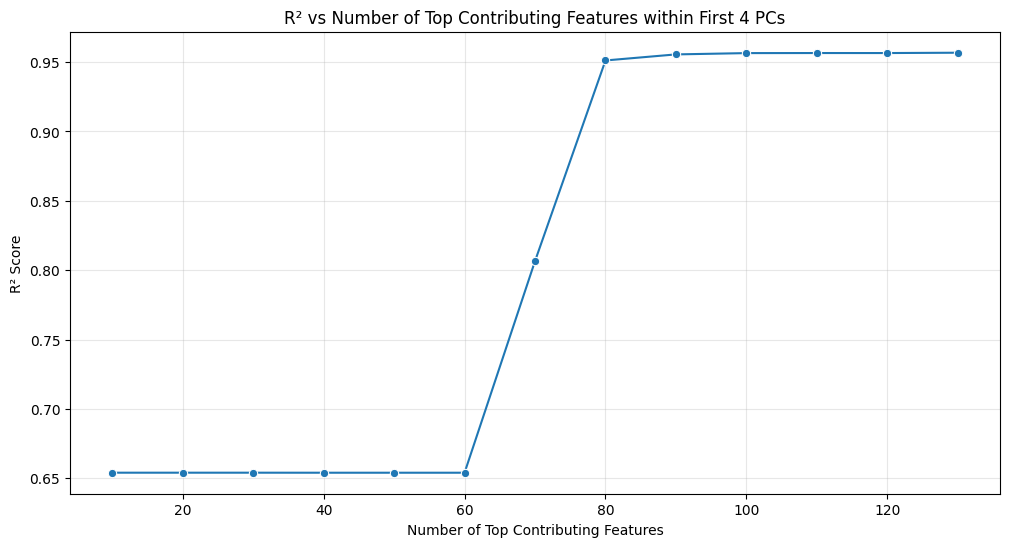

In [111]:
plot_df = pd.DataFrame(plot_data)
plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_df, x='Top_features', y='R2', marker='o')
plt.title('R² vs Number of Top Contributing Features within First 4 PCs')
plt.xlabel('Number of Top Contributing Features')
plt.ylabel('R² Score')
plt.grid(alpha=0.3)
plt.show()

It turns out you still need most of the top contributing features for the 4 principal components for good model performance. In this situation, using the top contributing PC features is probably not a good way to feature engineer a lighter model for ridership.

In [112]:
start_year = 2018
end_year = pd.Timestamp.today().year

#Get average seasonal and annual ridership
si_gdf_avg_ridership = si_gdf.copy()

for idx, station in si_gdf_avg_ridership.iterrows():
    map_id = station['MAP_ID']

    station_slice = station_ridership[
        (station_ridership['MAP_ID'] == map_id) &
        (station_ridership['year'] >= start_year) &
        (station_ridership['year'] <= end_year)
    ]

    seasonal_avg = (
        station_slice
        .groupby(['year', 'season'], as_index=False)['rides']
        .mean()
        .rename(columns={'rides': 'avg_rides'})
        .sort_values(['year', 'season'])
    )

    for _, season_row in seasonal_avg.iterrows():
        column_name = f"{int(season_row['year'])}_{season_row['season']}_avg_rides"
        si_gdf_avg_ridership.at[idx, column_name] = season_row['avg_rides']

    annual_avg = (
        station_slice
        .groupby('year', as_index=False)['rides']
        .mean()
        .rename(columns={'rides': 'avg_rides_annual'})
        .sort_values('year')
    )

    for _, year_row in annual_avg.iterrows():
        column_name = f"{int(year_row['year'])}_avg_rides"
        si_gdf_avg_ridership.at[idx, column_name] = year_row['avg_rides_annual']

for column in si_gdf_avg_ridership:
    print(column)


MAP_ID
STATION_NAME
latitude
longitude
ADA
RED
BLUE
G
BRN
P
Y
Pnk
O
N/S
E/W
geometry
geometry_mile
geometry_half_mile
B1_mile
B1_half_mile
B2_mile
B2_half_mile
B3_mile
B3_half_mile
C1_mile
C1_half_mile
C2_mile
C2_half_mile
C3_mile
C3_half_mile
DC_mile
DC_half_mile
DR_mile
DR_half_mile
DS_mile
DS_half_mile
DX_mile
DX_half_mile
M1_mile
M1_half_mile
M2_mile
M2_half_mile
M3_mile
M3_half_mile
PD_mile
PD_half_mile
PMD_mile
PMD_half_mile
PMD13_mile
PMD13_half_mile
POS_mile
POS_half_mile
RM_mile
RM_half_mile
RM4_mile
RM4_half_mile
RM4.5_mile
RM4.5_half_mile
RM5.5_mile
RM5.5_half_mile
RS_mile
RS_half_mile
RT_mile
RT_half_mile
T_mile
T_half_mile
2018_Fall_avg_rides
2018_Spring_avg_rides
2018_Summer_avg_rides
2018_Winter_avg_rides
2019_Fall_avg_rides
2019_Spring_avg_rides
2019_Summer_avg_rides
2019_Winter_avg_rides
2020_Fall_avg_rides
2020_Spring_avg_rides
2020_Summer_avg_rides
2020_Winter_avg_rides
2021_Fall_avg_rides
2021_Spring_avg_rides
2021_Summer_avg_rides
2021_Winter_avg_rides
2022_Fall_av


Average ridership statistics by cluster:


,n_stations,mean,median,std,min,max
cluster,,,,,,
0,15,833.85,591.93,514.96,423.55,1926.38
1,41,2851.92,2750.68,841.05,1666.23,5050.67
2,64,973.67,913.40,422.37,257.59,1981.22
3,11,7179.05,6664.45,1286.57,5733.98,10174.25
4,13,2897.77,3325.60,1004.08,1339.25,4172.97


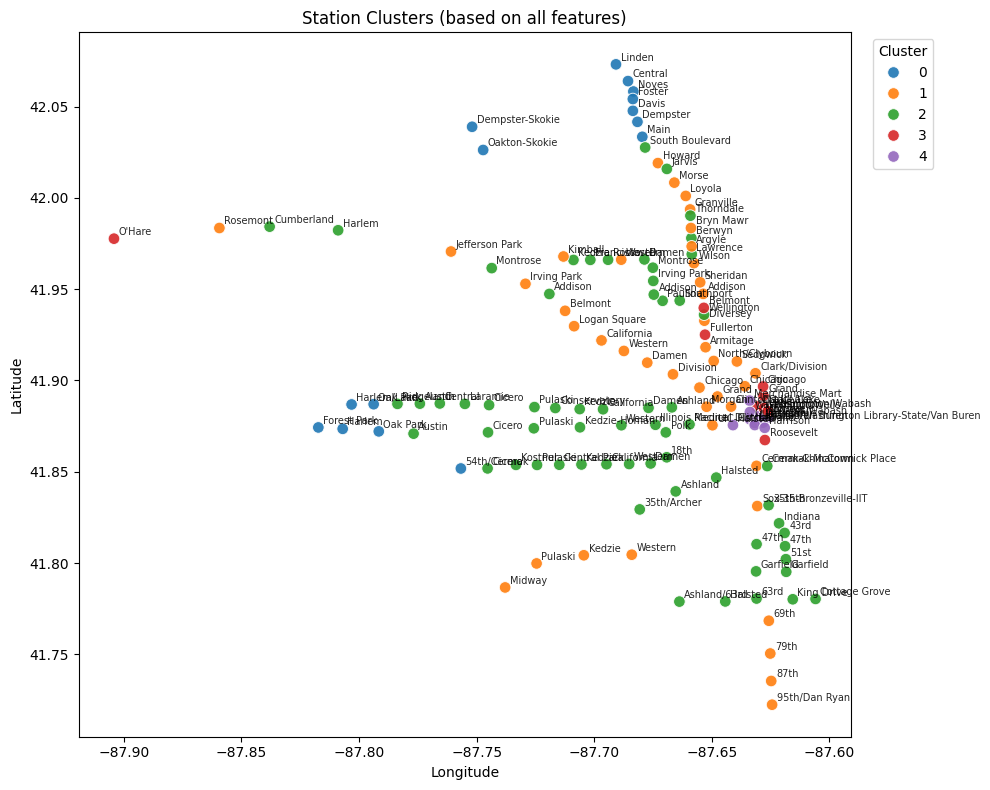

In [117]:

# Use all ridership-average features created in si_gdf_avg_ridership
exclude_cols = {"MAP_ID", "STATION_NAME", "stationname"}
clustering_cols = [
    c for c in si_gdf_avg_ridership.columns
    if c not in exclude_cols and not c.startswith("geometry")
]

if not clustering_cols:
    raise ValueError("No *_avg_rides columns found in si_gdf_avg_ridership.")

# Build clustering matrix (median-impute missing values)
X_cluster = si_gdf_avg_ridership[clustering_cols].copy()
X_cluster = X_cluster.apply(pd.to_numeric, errors="coerce")
X_cluster = X_cluster.fillna(X_cluster.median())

# Scale + cluster
X_scaled = StandardScaler().fit_transform(X_cluster)

k = 5  # adjust if needed
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
si_gdf_avg_ridership["cluster"] = kmeans.fit_predict(X_scaled)

# Quick summary
# Average ridership statistics by cluster
ridership_cols = [c for c in si_gdf_avg_ridership.columns if c.endswith("_avg_rides")]

if ridership_cols:
    cluster_ridership_stats = (
        si_gdf_avg_ridership
        .assign(_station_avg_rides=si_gdf_avg_ridership[ridership_cols].mean(axis=1, skipna=True))
        .groupby("cluster")["_station_avg_rides"]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .rename(columns={"count": "n_stations"})
        .round(2)
    )
    print("\nAverage ridership statistics by cluster:")
    display(cluster_ridership_stats)
else:
    print("No *_avg_rides columns found for ridership statistics.")

# Plot clusters by station location
plt.figure(figsize=(10, 8))
label_col = "STATION_NAME" if "STATION_NAME" in si_gdf_avg_ridership.columns else "stationname"

for _, row in si_gdf_avg_ridership.dropna(subset=["longitude", "latitude", [label_col][0]]).iterrows():
    plt.text(
        row["longitude"] + 0.002,
        row["latitude"] + 0.002,
        str(row[label_col]),
        fontsize=7,
        alpha=0.85
    )
sns.scatterplot(
    data=si_gdf_avg_ridership,
    x="longitude",
    y="latitude",
    hue="cluster",
    palette="tab10",
    s=70,
    alpha=0.9
)
plt.title("Station Clusters (based on all features)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [122]:
# Ablation testing to see which features are most important for clustering
from sklearn.metrics import silhouette_score
feature_importance = {}

# Calculate baseline silhouette score
baseline_score = silhouette_score(X_scaled, si_gdf_avg_ridership["cluster"])
print(f"Baseline silhouette score: {baseline_score:.4f}\n")

for col in clustering_cols:
    X_ablated = X_cluster.drop(columns=[col])
    X_ablated_scaled = StandardScaler().fit_transform(X_ablated)
    kmeans_ablated = KMeans(n_clusters=k, n_init=10)
    labels_ablated = kmeans_ablated.fit_predict(X_ablated_scaled)
    score = silhouette_score(X_ablated_scaled, labels_ablated)
    feature_importance[col] = score
feature_importance_df = pd.DataFrame.from_dict(feature_importance, orient="index", columns=["silhouette_score"])
feature_importance_df = feature_importance_df.sort_values(by="silhouette_score", ascending=True)
print("Most important features based on silhouette score after ablation (lower score indicates higher importance):")
display(feature_importance_df)

Baseline silhouette score: 0.2306

Most important features based on silhouette score after ablation (lower score indicates higher importance):


,silhouette_score
2022_Spring_avg_rides,0.222043
RT_half_mile,0.222593
C1_half_mile,0.224302
RM_mile,0.224667
cluster,0.225230
...,...
G,0.233445
Pnk,0.233452
BLUE,0.233611
ADA,0.234230


- It looks like each individual feature using clustering doesn't affect the sillhouette score that much, indicating redundant features or weak clusters. The sillhouette score of the unablated model is only 0.23, which isn't the strongest clustering. Let's try again with fewer clusters

Silhouette score with 3 clusters: 0.3036

Average ridership statistics by cluster:


,n_stations,mean,median,std,min,max
cluster,,,,,,
0,16,910.02,633.07,583.40,423.55,2052.66
1,26,5303.17,4638.24,1878.55,3273.67,10174.25
2,102,1528.91,1422.94,869.36,257.59,3754.76


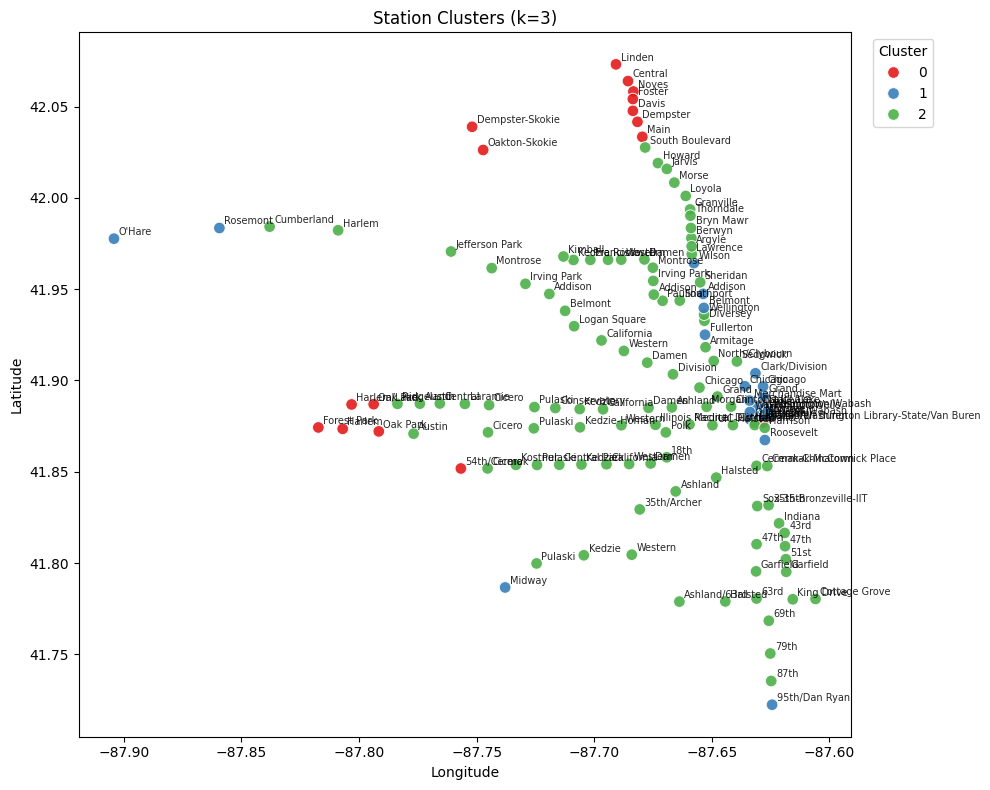

In [123]:
# Retry clustering with k=3 for stronger, more distinct clusters
k = 3

# Work with a copy
si_gdf_avg_ridership_k3 = si_gdf_avg_ridership.copy()

kmeans_3 = KMeans(n_clusters=k, random_state=42, n_init=10)
si_gdf_avg_ridership_k3["cluster"] = kmeans_3.fit_predict(X_scaled)

# Calculate silhouette score
silhouette_3 = silhouette_score(X_scaled, si_gdf_avg_ridership_k3["cluster"])
print(f"Silhouette score with {k} clusters: {silhouette_3:.4f}\n")

# Average ridership statistics by cluster
ridership_cols = [c for c in si_gdf_avg_ridership_k3.columns if c.endswith("_avg_rides")]

if ridership_cols:
    cluster_ridership_stats = (
        si_gdf_avg_ridership_k3
        .assign(_station_avg_rides=si_gdf_avg_ridership_k3[ridership_cols].mean(axis=1, skipna=True))
        .groupby("cluster")["_station_avg_rides"]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .rename(columns={"count": "n_stations"})
        .round(2)
    )
    print("Average ridership statistics by cluster:")
    display(cluster_ridership_stats)

# Plot clusters by station location
plt.figure(figsize=(10, 8))
label_col = "STATION_NAME" if "STATION_NAME" in si_gdf_avg_ridership_k3.columns else "stationname"

for _, row in si_gdf_avg_ridership_k3.dropna(subset=["longitude", "latitude", label_col]).iterrows():
    plt.text(
        row["longitude"] + 0.002,
        row["latitude"] + 0.002,
        str(row[label_col]),
        fontsize=7,
        alpha=0.85
    )
sns.scatterplot(
    data=si_gdf_avg_ridership_k3,
    x="longitude",
    y="latitude",
    hue="cluster",
    palette="Set1",
    s=70,
    alpha=0.9
)
plt.title(f"Station Clusters (k={k})")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Fewer clusters show moderate improvements to sillhouette score. Tradeoff of clearer clusters for nuance